In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.formula.api import mixedlm
from matplotlib import colors

In [22]:
### 解决字体乱码问题
# 1. 设置中文字体（按优先级排序）
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

#plt.rcParams['font.size'] = 12                # 设置字体大小


In [23]:
df = pd.read_excel('./附件.xlsx', sheet_name=0).drop(['序号','IVF妊娠','末次月经','检测日期','原始读段数','在参考基因组上比对的比例','重复读段的比例'],axis=1)
df4 = pd.read_excel('./附件.xlsx', sheet_name=1).drop(['序号','IVF妊娠','末次月经','检测日期','原始读段数','在参考基因组上比对的比例','重复读段的比例'],axis=1)
df12 = pd.read_excel('./热力图.xlsx', sheet_name=0)

In [24]:
#转换孕周
def convert1(s: str) -> float:
    s = s.strip().lower() 
    if "w" not in s:
        return float(s)
    front, back = s.split("w", 1)
    front = int(front) if front else 0
    back = int(back) if back else 0
    return front + back / 7.0

In [25]:
#转换编号1
def convert2(data):
    if isinstance(data, str):
        return int(data.lstrip("A"))
    else:
        return [int(s.lstrip("A")) for s in data if isinstance(s, str)]

In [26]:
#转换编号2
def convert3(data):
    if isinstance(data, str):
        return int(data.lstrip("B"))
    else:
        return [int(s.lstrip("B")) for s in data if isinstance(s, str)]

In [27]:
#转换非整倍体
df4['T13'] = df4['染色体的非整倍体'].apply(lambda x: 1 if pd.notna(x) and 'T13' in str(x) else 0)
df4['T18'] = df4['染色体的非整倍体'].apply(lambda x: 1 if pd.notna(x) and 'T18' in str(x) else 0)
df4['T21'] = df4['染色体的非整倍体'].apply(lambda x: 1 if pd.notna(x) and 'T21' in str(x) else 0)
df4['状态'] = df4['T13'] | df4['T18'] | df4['T21']
df4.iloc[:,-5:].head()

,胎儿是否健康,T13,T18,T21,状态
0,是,0,0,0,0
1,是,0,0,0,0
2,是,0,0,0,0
3,是,0,0,0,0
4,是,0,0,0,0


In [28]:
#转换怀孕次数
def convert4(value):
    if pd.isna(value):
        return np.nan
    value_str = str(value).strip()
    if value_str == '≥3':
        return 3
    return int(value_str)

In [29]:
#转换/标准化字段
df['胎儿是否健康'] = df['胎儿是否健康'].str.replace('是','1')
df['胎儿是否健康'] = df['胎儿是否健康'].str.replace('否','0')
df['检测孕周'] = df['检测孕周'].str.replace('+','')
df['检测孕周'] = df['检测孕周'].apply(convert1)
df['孕妇代码'] = df['孕妇代码'].apply(convert2)
df['怀孕次数_数值'] = df['怀孕次数'].apply(convert4)
df['检测孕周'] = pd.to_numeric(df['检测孕周'])
df['孕妇代码'] = pd.to_numeric(df['孕妇代码'])
df['胎儿是否健康'] = pd.to_numeric(df['胎儿是否健康'])
df.drop(['染色体的非整倍体'],axis = 1)
df = df.drop('怀孕次数', axis=1)

In [30]:
df.to_excel('3_1.xlsx')

In [31]:
#转换/标准化字段
df4['胎儿是否健康'] = df4['胎儿是否健康'].str.replace('是','1')
df4['胎儿是否健康'] = df4['胎儿是否健康'].str.replace('否','0')
df4['检测孕周'] = df4['检测孕周'].str.replace('+','')
df4['检测孕周'] = df4['检测孕周'].apply(convert1)
df4['孕妇代码'] = df4['孕妇代码'].apply(convert3)
df4['怀孕次数_数值'] = df4['怀孕次数'].apply(convert4)
df4['检测孕周'] = pd.to_numeric(df4['检测孕周'])
df4['孕妇代码'] = pd.to_numeric(df4['孕妇代码'])
df4['胎儿是否健康'] = pd.to_numeric(df4['胎儿是否健康'])
df4.drop(['染色体的非整倍体'],axis = 1)
df4 = df4.drop('怀孕次数', axis=1)

In [32]:
# 修正：原代码 df4=df.to_csv() 会把 df4 变成字符串，导致后续无法当 DataFrame 使用
# 如果意图是保存 df4：
df4.to_csv('df4.csv', index=False)
# 如果意图是保存 df1，请使用：
# df1.to_csv('df1.csv', index=False)

In [33]:
#第一问所需数据
df11=df.loc[:,['孕妇代码',	'检测抽血次数',	'检测孕周',	'孕妇BMI',	'Y染色体浓度']]

In [34]:
#模型假设二的实现
same_indices = []
start_index = 0
for i in range(1, len(df11)):
    if df11['检测抽血次数'][i] != df11['检测抽血次数'][i - 1]:
        same_indices.append((start_index, i - 1))
        start_index = i
same_indices.append((start_index, len(df11) - 1))
df1 = pd.DataFrame()
for start, end in same_indices:
    if start == end:
        df1 = pd.concat([df1, df11.iloc[[start]]], ignore_index=True)
    else:
        mean_row = df11.iloc[start:end + 1].mean()
        mean_row['孕妇代码'] = df11['孕妇代码'][start]
        mean_row['检测抽血次数'] = df11['检测抽血次数'][start]
        df1 = pd.concat([df1, mean_row.to_frame().T], ignore_index=True)

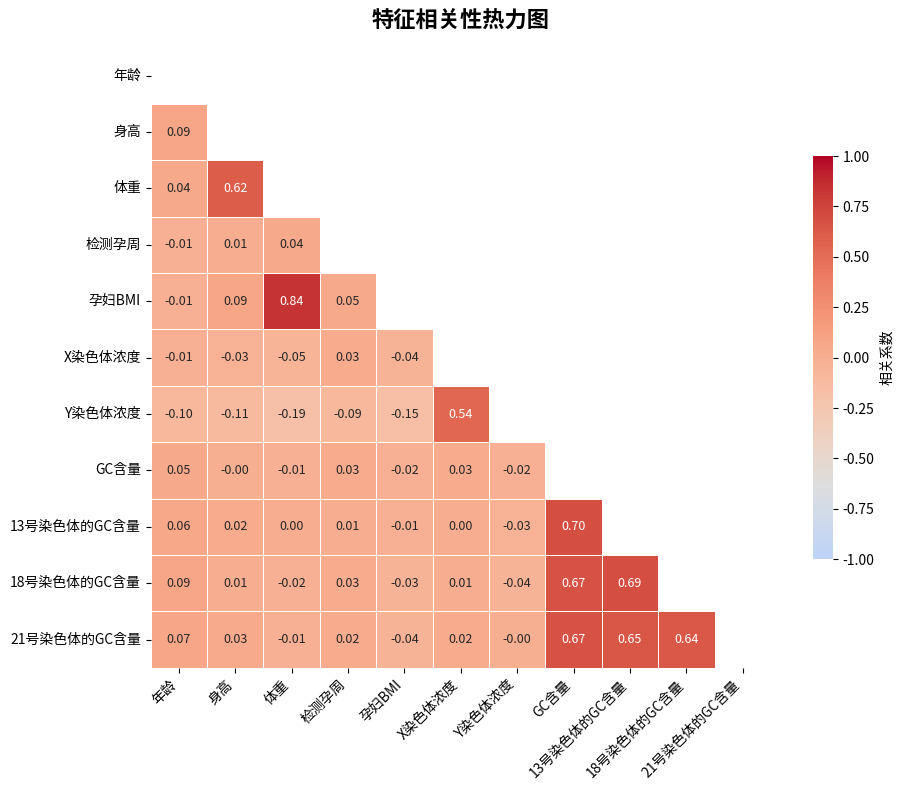

In [35]:
corr = df12.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8), dpi=100)
norm = colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
# 可选调色板: ['BrBG','PuOr','PRGn','PiYG','coolwarm','Spectral','RdYlBu','cividis']
cmap_choice = 'coolwarm'
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap=cmap_choice,
    norm=norm,
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink':0.65,'label':'相关系数'},
    square=True,
    annot_kws={'size':9}
)
plt.title(f'特征相关性热力图', fontsize=16, pad=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

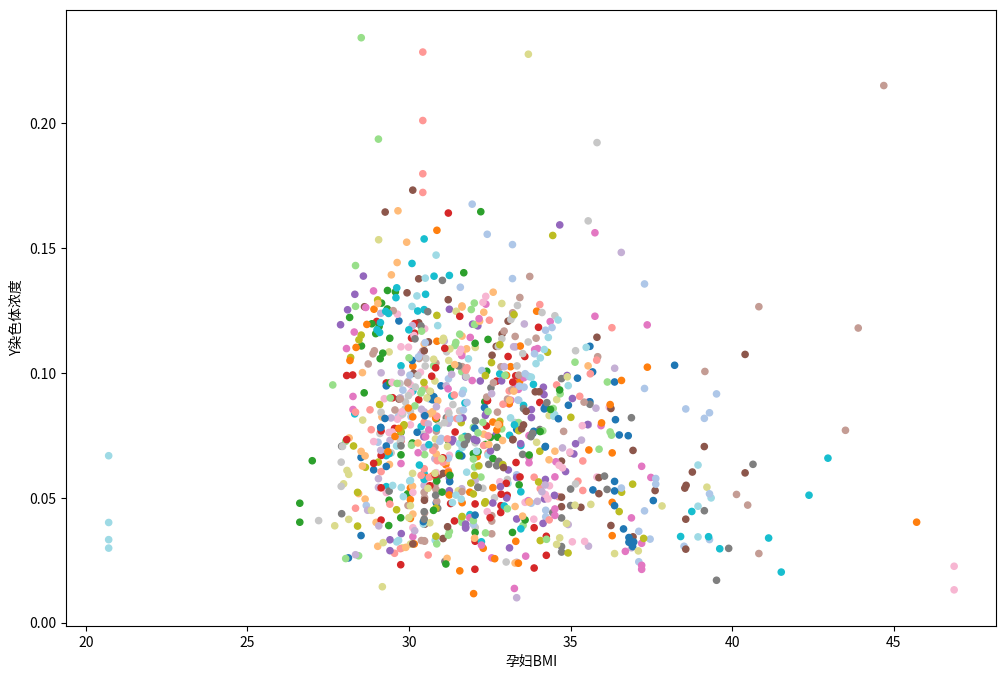

In [36]:
fig, ax = plt.subplots(figsize=(12, 8))
x1 = df1['孕妇BMI']
x2 = df1['检测孕周']
y = df1['Y染色体浓度']
sizes = 20
unique_codes = df1['孕妇代码'].unique()
# 创建一个字典，用于存储每个孕妇代码的颜色
num_colors = len(unique_codes)
color_map = plt.colormaps['tab20'].resampled(20)
# 为每个孕妇代码分配颜色
color_ranges = {code: color_map(i % 20) for i, code in enumerate(unique_codes)}
colors = [color_ranges[code] for code in df1['孕妇代码']]
plt.xlabel('孕妇BMI')
plt.ylabel('Y染色体浓度')
ax.scatter(x1, y, s=sizes, c=colors)
plt.show()

Text(0.5, 1.0, 'Q-Q Plot (fit=True)')

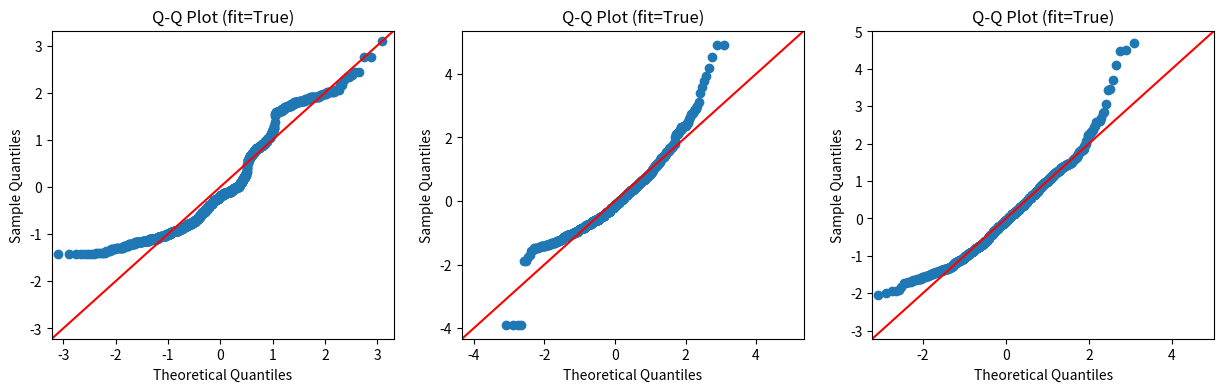

In [37]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
sm.qqplot(df1['孕妇BMI'], line='45', fit=True, ax=ax2)
ax2.set_title('Q-Q Plot (fit=True)')
sm.qqplot(df1['Y染色体浓度'], line='45', fit=True, ax=ax3)
ax3.set_title('Q-Q Plot (fit=True)')
sm.qqplot(df1['检测孕周'], line='45', fit=True, ax=ax1)
ax1.set_title('Q-Q Plot (fit=True)')

In [38]:
model = mixedlm("Y染色体浓度 ~ 孕妇BMI + 检测孕周", df1, groups=df1["孕妇代码"])
# 拟合模型
result = model.fit()
# 打印模型摘要
residuals = result.resid

# 打印残差
print(residuals)

0      -0.006315
1      -0.009519
2       0.008202
3      -0.004863
4       0.021832
          ...   
1009    0.010014
1010   -0.002018
1011   -0.001642
1012    0.003325
1013    0.013574
Length: 1014, dtype: float64


/home/terabyte/anaconda3/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [39]:
random_effects = result.random_effects

# 打印随机效应
print(random_effects)

{np.float64(1.0): Group   -0.035305
dtype: float64, np.float64(2.0): Group   -0.029752
dtype: float64, np.float64(3.0): Group   -0.02146
dtype: float64, np.float64(4.0): Group   -0.020059
dtype: float64, np.float64(5.0): Group    0.015738
dtype: float64, np.float64(6.0): Group    0.00153
dtype: float64, np.float64(7.0): Group   -0.045581
dtype: float64, np.float64(8.0): Group   -0.037164
dtype: float64, np.float64(9.0): Group   -0.004054
dtype: float64, np.float64(10.0): Group   -0.053136
dtype: float64, np.float64(11.0): Group   -0.025042
dtype: float64, np.float64(12.0): Group   -0.028989
dtype: float64, np.float64(13.0): Group    0.03172
dtype: float64, np.float64(14.0): Group   -0.023716
dtype: float64, np.float64(15.0): Group   -0.025172
dtype: float64, np.float64(16.0): Group    0.002454
dtype: float64, np.float64(17.0): Group   -0.009745
dtype: float64, np.float64(18.0): Group   -0.030159
dtype: float64, np.float64(19.0): Group   -0.017787
dtype: float64, np.float64(20.0): Group

In [40]:
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Y染色体浓度   
No. Observations: 1014    Method:             REML     
No. Groups:       267     Scale:              0.0003   
Min. group size:  1       Log-Likelihood:     2345.0684
Max. group size:  5       Converged:          Yes      
Mean group size:  3.8                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.066    0.016  4.025 0.000  0.034  0.099
孕妇BMI        -0.001    0.001 -2.435 0.015 -0.002 -0.000
检测孕周          0.003    0.000 18.785 0.000  0.003  0.003
Group Var     0.001    0.005                           

